<a href="https://colab.research.google.com/github/michalejan/EEG-Neural-Representation-Prediciton-Model_BA/blob/main/ML_ClassificationPipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 12/04/2026 ML Pipeline for EEG data classification on the Kuo & Prat (2023) data set.
ML MODELS:
*   Linear Discriminant Analysis (LDA)
*   Suuport Vector Machine (SVM)
*   Random Forest (RF)





## 1. Necessary downloads and environment setup

In [3]:
!pip install -q mne scikit-learn pandas

In [10]:
import mne
import numpy as np
import os
import glob
from google.colab import drive
import pandas as pd

In [5]:
print("Mounting Google Drive...")
drive.mount('/content/drive')

Mounting Google Drive...
Mounted at /content/drive


In [11]:
# loading the .fif files + metadata from subs from gdrive
base_dir = "/content/drive/MyDrive/EEG_data"
epochs_dir = os.path.join(base_dir, "P600_Results/eeg_cleaned_fifs")
metadata_path = "/content/drive/MyDrive/EEG_data/P600_Results/participants_metadata.txt"
print("\n--- LOADING METADATA ---")
meta_df = pd.read_csv(metadata_path, sep='\t')
# verifying the directory of the fif files
print("\n--- SCANNING DIRECTORY ---")
fif_files = glob.glob(os.path.join(epochs_dir, '*_ML_clean_epo.fif'))
# extracting the subs from the filenames
processed_subs = [os.path.basename(f).split('_')[0] for f in fif_files]
processed_subs.sort()

print(f"Found {len(processed_subs)} preprocessed .fif files in the directory.")



--- LOADING METADATA ---

--- SCANNING DIRECTORY ---
Found 45 preprocessed .fif files in the directory.


In [12]:
# verifying the number of NOVICES and EXPERTS in the datset

analysis_df = meta_df[meta_df['participant_id'].isin(processed_subs)].copy()

novice_count = len(analysis_df[analysis_df['python_expertise'] == 'Novice'])
expert_count = len(analysis_df[analysis_df['python_expertise'] == 'Expert'])
print(f"Mapped groups -> Novices: {novice_count} | Experts: {expert_count}")

Mapped groups -> Novices: 18 | Experts: 27


## 2. LOADING THE FIRST SUB TO VERIFY THE PIPELINE




In [17]:
if len(fif_files) > 0:
    test_sub_id = analysis_df['participant_id'].iloc[0]
    test_file = os.path.join(epochs_dir, f"{test_sub_id}_ML_clean_epo.fif")

    print(f"\n--- SANITY CHECK: {test_sub_id} ---")

    # extracting numpy arrays
    epochs_test = mne.read_epochs(test_file, preload=True, verbose=False)
    # cropping to 500ms-800ms
    epochs_test_p600 = epochs_test.copy().crop(tmin=0.5, tmax=0.8)
    # FEATURE EXTRACTION
    X_test = epochs_test_p600.get_data()

    print("\n--- DATA CHECK ---")
    print(f"Number of total epochs (trials): {len(epochs_test)}")
    print(f"Electrodes (Channels) present: {epochs_test.ch_names}")
    print(f"Original Time window: {epochs_test.times[0]}s to {epochs_test.times[-1]}s")
    print(f"Event IDs in this file: {epochs_test.event_id}")

    print(f"Number of channels: {len(epochs_test_p600.ch_names)}")
    print(f"Timepoints in P600 window (500-800ms at 100Hz): {X_test.shape[2]}")
    print(f"Shape of X matrix (Trials, Channels, Timepoints): {X_test.shape}")
else:
    print("------ ERROR: No .fif files found. Check the epochs_dir path.")



--- SANITY CHECK: sub-001 ---

--- DATA CHECK ---
Number of total epochs (trials): 79
Electrodes (Channels) present: ['Fp1', 'AF3', 'F7', 'F3', 'FC1', 'FC5', 'T7', 'C3', 'CP1', 'CP5', 'P7', 'P3', 'Pz', 'PO3', 'O1', 'Oz', 'O2', 'PO4', 'P4', 'P8', 'CP6', 'CP2', 'C4', 'T8', 'FC6', 'FC2', 'F4', 'F8', 'AF4', 'Fp2', 'Fz', 'Cz', 'LIO', 'ROC']
Original Time window: -0.1s to 1.19s
Event IDs in this file: {'B1,3,5,13(110)/B17,19,21,29(111)': 4, 'B1,4,6,14(220)/B17,20,22,30(221)': 7, 'B1,3,5,9(115)/B17,19,21,25(116)': 10, 'B1,4,6,10(225)/B17,20,22,26(226)': 16}
Number of channels: 34
Timepoints in P600 window (500-800ms at 100Hz): 31
Shape of X matrix (Trials, Channels, Timepoints): (79, 34, 31)


## 3. Classification pipeline of all subs

In [18]:
#setup and initilization

import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from mne.decoding import Vectorizer


In [19]:
print("--- INITIALIZING THE MASTER PIPELINE ---\n")
# ROI channels (Centro-Parietal)
roi_channels = ['CP1', 'CP2', 'CP5', 'CP6', 'P3', 'P4', 'P7', 'P8', 'Pz']
print(roi_channels)


--- INITIALIZING THE MASTER PIPELINE ---

['CP1', 'CP2', 'CP5', 'CP6', 'P3', 'P4', 'P7', 'P8', 'Pz']


In [22]:
# 3 ML MODELS

models = {
    'LDA': make_pipeline(Vectorizer(), StandardScaler(), LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
    'SVM': make_pipeline(Vectorizer(), StandardScaler(), SVC(kernel='linear', random_state=42)),
    'RandomForest': make_pipeline(Vectorizer(), StandardScaler(), RandomForestClassifier(n_estimators=100, random_state=42))
}
# CROSS-VALIDATION; 4-1 train-test ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 3.1 CLASSIFICATION PILOT TEST ON SUB-001

In [26]:
print("--- PILOT TEST ON 1 SUBJECT ---")

pilot_row = analysis_df.iloc[0]
sub_id = pilot_row['participant_id']
expertise = pilot_row['python_expertise']
file_path = os.path.join(epochs_dir, f"{sub_id}_ML_clean_epo.fif")

pilot_results = []

try:
    # Load the clean epoched data
    epochs = mne.read_epochs(file_path, preload=True, verbose=False)

    # Mapping the triggers
    control_codes = [c for n, c in epochs.event_id.items() if '(110)' in n or '(115)' in n]
    violation_codes = [c for n, c in epochs.event_id.items() if '(220)' in n or '(225)' in n]
    valid_codes = control_codes + violation_codes

    # filtering epochs and creating binary classes
    epochs = epochs[np.isin(epochs.events[:, 2], valid_codes)]
    y = np.array([0 if ev in control_codes else 1 for ev in epochs.events[:, 2]])

    # TIME WINDOW FOR THE P600
    epochs_p600 = epochs.copy().crop(tmin=0.5, tmax=0.8)

    # Defining all 3 tiers of configurations
    tier_configs = {
        'Tier_A_All_Chans': epochs_p600.ch_names,
        'Tier_B_ROI_Aggregate': [ch for ch in roi_channels if ch in epochs_p600.ch_names]
    }
    # individual ROI channels tier
    for ch in roi_channels:
        if ch in epochs_p600.ch_names:
            tier_configs[f'Tier_C_{ch}'] = [ch]

    print(f"Testing {len(tier_configs)} configurations across 3 models for {sub_id}...")

    # running the models
    for config_name, channels in tier_configs.items():
        epochs_tier = epochs_p600.copy().pick(channels)
        X = epochs_tier.get_data()

        for model_name, clf in models.items():
            scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
            pilot_results.append({
                'Subject': sub_id,
                'Expertise': expertise,
                'Config_Name': config_name,
                'Model': model_name,
                'Accuracy': scores.mean() * 100
            })

    pilot_df = pd.DataFrame(pilot_results)
    print(" Pilot test successful! \nFIRST 5 ROWS OF THE TABLE:")
    display(pilot_df.head())

except Exception as e:
    print(f"-------- Error during pilot test: {e}")

--- PILOT TEST ON 1 SUBJECT ---
Testing 11 configurations across 3 models for sub-001...
 Pilot test successful! 
FIRST 5 ROWS OF THE TABLE:


,Subject,Expertise,Config_Name,Model,Accuracy
0,sub-001,Novice,Tier_A_All_Chans,LDA,46.833333
1,sub-001,Novice,Tier_A_All_Chans,SVM,48.166667
2,sub-001,Novice,Tier_A_All_Chans,RandomForest,42.916667
3,sub-001,Novice,Tier_B_ROI_Aggregate,LDA,44.250000
4,sub-001,Novice,Tier_B_ROI_Aggregate,SVM,47.916667


### 3.2 MASTER CLASSIFICATION PIPELINE FOR ALL SUBS

In [27]:
print("--- THE MASTER CLASSIFICATION LOOP ---")

master_results_list = []
print(f"classification loop for {len(analysis_df)} subjects.\n")

### THE LOOP

for idx, row in analysis_df.iterrows():
    sub_id = row['participant_id']
    expertise = row['python_expertise']

    file_path = os.path.join(epochs_dir, f"{sub_id}_ML_clean_epo.fif")

    try:
        # Load the clean epoched data
        epochs = mne.read_epochs(file_path, preload=True, verbose=False)

        # Mapping the triggers
        control_codes = [c for n, c in epochs.event_id.items() if '(110)' in n or '(115)' in n]
        violation_codes = [c for n, c in epochs.event_id.items() if '(220)' in n or '(225)' in n]
        valid_codes = control_codes + violation_codes

        # filtering epochs and creating binary classes
        epochs = epochs[np.isin(epochs.events[:, 2], valid_codes)]
        y = np.array([0 if ev in control_codes else 1 for ev in epochs.events[:, 2]])

        # Safety check: ensure both conditions exist before running ML
        if len(np.unique(y)) < 2:
            print(f"XXXXXX {sub_id} skipped: Missing one condition class.")
            continue

        # TIME WINDOW FOR THE P600
        epochs_p600 = epochs.copy().crop(tmin=0.5, tmax=0.8)

        # Defining all 3 tiers of configurations
        tier_configs = {
            'Tier_A_All_Chans': epochs_p600.ch_names,
            'Tier_B_ROI_Aggregate': [ch for ch in roi_channels if ch in epochs_p600.ch_names]
        }
        # individual ROI channels tier
        for ch in roi_channels:
            if ch in epochs_p600.ch_names:
                tier_configs[f'Tier_C_{ch}'] = [ch]

        # RUNNING THE MODELS
        for config_name, channels in tier_configs.items():

            epochs_tier = epochs_p600.copy().pick(channels)
            X = epochs_tier.get_data()

            for model_name, clf in models.items():
                scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)

                master_results_list.append({
                    'Subject': sub_id,
                    'Expertise': expertise,
                    'Config_Name': config_name,
                    'Model': model_name,
                    'Accuracy': scores.mean() * 100
                })

        print(f"SUCCESS; Processed {sub_id} ({expertise})")

    except Exception as e:
        print(f"XXXXX Error on {sub_id}: {e}")

# converting results
master_results_df = pd.DataFrame(master_results_list)

# saving a backup to gdrive
backup_path = os.path.join(base_dir, "P600_Results", "Master_ML_Results.csv")
master_results_df.to_csv(backup_path, index=False)

print("\n---- CLASSIFICATION COMPLETE -----")
print(f"Total rows in master result sheet: {len(master_results_df)}")
print(f"Results backed up to: {backup_path}")

--- THE MASTER CLASSIFICATION LOOP ---
classification loop for 45 subjects.

SUCCESS; Processed sub-001 (Novice)
SUCCESS; Processed sub-002 (Novice)
SUCCESS; Processed sub-003 (Novice)
SUCCESS; Processed sub-004 (Novice)
SUCCESS; Processed sub-005 (Novice)
SUCCESS; Processed sub-006 (Novice)
SUCCESS; Processed sub-008 (Expert)
SUCCESS; Processed sub-010 (Novice)
SUCCESS; Processed sub-011 (Expert)
SUCCESS; Processed sub-012 (Expert)
SUCCESS; Processed sub-013 (Expert)
SUCCESS; Processed sub-014 (Novice)
SUCCESS; Processed sub-015 (Expert)
SUCCESS; Processed sub-016 (Expert)
SUCCESS; Processed sub-017 (Expert)
SUCCESS; Processed sub-020 (Novice)
SUCCESS; Processed sub-021 (Expert)
SUCCESS; Processed sub-022 (Novice)
SUCCESS; Processed sub-023 (Expert)
SUCCESS; Processed sub-024 (Expert)
SUCCESS; Processed sub-027 (Expert)
SUCCESS; Processed sub-029 (Expert)
SUCCESS; Processed sub-031 (Expert)
SUCCESS; Processed sub-032 (Expert)
SUCCESS; Processed sub-033 (Expert)
SUCCESS; Processed sub-

In [32]:
print("--- SUMMARY OF MODEL ACCURACY BY TIER ---")

# Using pivot_table to create a clean, side-by-side comparison matrix
tier_summary = master_results_df.pivot_table(
    index='Config_Name',
    columns='Model',
    values='Accuracy',
    aggfunc='mean'  # calculating the mean average
)

# sorting the tiers
tier_summary = tier_summary.sort_index()

# displaying the table
display(tier_summary.round(2))
# BEST COMBINATIONS
best_overall = master_results_df.groupby(['Config_Name', 'Model'])['Accuracy'].mean().idxmax()
best_acc = master_results_df.groupby(['Config_Name', 'Model'])['Accuracy'].mean().max()

print("\n---- THE OVERALL WINNER ----")
print(f"Best Configuration: {best_overall[0]}")
print(f"Best Model: {best_overall[1]}")
print(f"Peak Group Accuracy: {best_acc:.2f}%")

--- SUMMARY OF MODEL ACCURACY BY TIER ---


Model,LDA,RandomForest,SVM
Config_Name,,,
Tier_A_All_Chans,52.94,55.27,53.23
Tier_B_ROI_Aggregate,53.26,55.28,52.45
Tier_C_CP1,49.43,51.02,48.74
Tier_C_CP2,51.26,51.62,51.35
Tier_C_CP5,51.86,50.98,51.04
Tier_C_CP6,50.46,51.74,51.07
Tier_C_P3,50.11,49.18,49.67
Tier_C_P4,51.70,51.33,51.71
Tier_C_P7,51.78,53.05,51.51



---- THE OVERALL WINNER ----
Best Configuration: Tier_B_ROI_Aggregate
Best Model: RandomForest
Peak Group Accuracy: 55.28%


In [34]:
print("--- ACCURACY BY EXPERTISE LEVEL ---")

# View of all of the configurations
print("1. GLOBAL PERFORMANCE (Averaged across all Tiers & Channels)")
global_expertise = master_results_df.pivot_table(
    index='Expertise',
    columns='Model',
    values='Accuracy',
    aggfunc='mean'
)
display(global_expertise.round(2))

# Centro-Parietal configuration
print("\n2. TIER B (Centro-Parietal ROI) ONLY: Novice vs. Expert")
tier_b_df = master_results_df[master_results_df['Config_Name'] == 'Tier_B_ROI_Aggregate']

tier_b_expertise = tier_b_df.pivot_table(
    index='Expertise',
    columns='Model',
    values='Accuracy',
    aggfunc=['mean', 'std'] # std - standard deviation
)
display(tier_b_expertise.round(2))

# 3. Calculate the exact difference for the overall winner
expert_rf_acc = tier_b_df[(tier_b_df['Expertise'] == 'Expert') & (tier_b_df['Model'] == 'RandomForest')]['Accuracy'].mean()
novice_rf_acc = tier_b_df[(tier_b_df['Expertise'] == 'Novice') & (tier_b_df['Model'] == 'RandomForest')]['Accuracy'].mean()

print("\n DEEP DIVE: Random Forest on Tier B")
print(f"Expert Accuracy: {expert_rf_acc:.2f}%")
print(f"Novice Accuracy: {novice_rf_acc:.2f}%")
print(f"Difference: {expert_rf_acc - novice_rf_acc:.2f}%")

--- ACCURACY BY EXPERTISE LEVEL ---
1. GLOBAL PERFORMANCE (Averaged across all Tiers & Channels)


Model,LDA,RandomForest,SVM
Expertise,,,
Expert,52.14,53.04,51.85
Novice,50.09,50.47,49.97



2. TIER B (Centro-Parietal ROI) ONLY: Novice vs. Expert


mean                       std                   
Model       LDA RandomForest    SVM   LDA RandomForest   SVM
Expertise                                                   
Expert     55.7        57.69  54.31  7.62         9.00  7.65
Novice     49.6        51.68  49.65  7.04         7.39  7.52


 DEEP DIVE: Random Forest on Tier B
Expert Accuracy: 57.69%
Novice Accuracy: 51.68%
Difference: 6.01%


## 4. VISUALIZING RESULTS

--- STATISTICAL TESTING & VISUALIZATION ---

 ----- STATISTICAL RESULTS -----
Expert vs. Chance (50%): t=4.44, p=0.0001
   -> SIGNIFICANT: Experts are decoded reliably above chance

Expert vs. Novice: t=2.35, p=0.0116
   -> SIGNIFICANT: Experts have a significantly more classifiable P600 than Novices

----- Plot saved to your Drive!


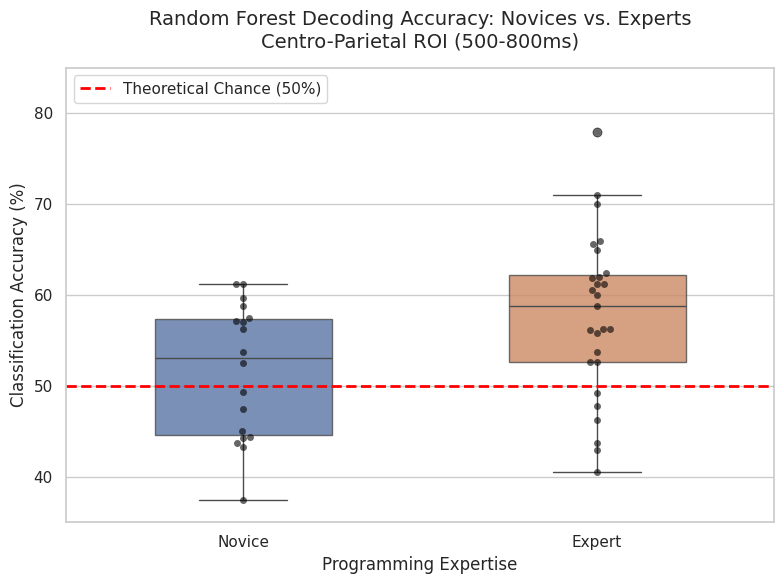

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

print("--- STATISTICAL TESTING & VISUALIZATION ---")

# isolating the Tier B RF model results
tier_b_rf = master_results_df[(master_results_df['Config_Name'] == 'Tier_B_ROI_Aggregate') &
                              (master_results_df['Model'] == 'RandomForest')]

expert_scores = tier_b_rf[tier_b_rf['Expertise'] == 'Expert']['Accuracy']
novice_scores = tier_b_rf[tier_b_rf['Expertise'] == 'Novice']['Accuracy']

# statistical testing
chance_level = 50.0

# One-sample t-test: Are Experts significantly above 50% chance?
t_stat_exp, p_val_exp = stats.ttest_1samp(expert_scores, chance_level, alternative='greater')

# Independent t-test: Are Experts significantly better than Novices?
t_stat_comp, p_val_comp = stats.ttest_ind(expert_scores, novice_scores, alternative='greater')

print("\n ----- STATISTICAL RESULTS -----")
print(f"Expert vs. Chance (50%): t={t_stat_exp:.2f}, p={p_val_exp:.4f}")
if p_val_exp < 0.05:
    print("   -> SIGNIFICANT: Experts are decoded reliably above chance")
else:
    print("   -> Not statistically significant.")

print(f"\nExpert vs. Novice: t={t_stat_comp:.2f}, p={p_val_comp:.4f}")
if p_val_comp < 0.05:
    print("   -> SIGNIFICANT: Experts have a significantly more classifiable P600 than Novices")
else:
    print("   -> Trend present, but not statistically significant at p<0.05.")

# visualization
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# boxplot
ax = sns.boxplot(x='Expertise', y='Accuracy', data=tier_b_rf,
                 palette=['#4C72B0', '#DD8452'], width=0.5, boxprops=dict(alpha=0.8))

sns.swarmplot(x='Expertise', y='Accuracy', data=tier_b_rf, color='black', alpha=0.6)

# Formatting
plt.axhline(50, color='red', linestyle='--', linewidth=2, label='Theoretical Chance (50%)')
plt.title('Random Forest Decoding Accuracy: Novices vs. Experts\nCentro-Parietal ROI (500-800ms)', fontsize=14, pad=15)
plt.ylabel('Classification Accuracy (%)', fontsize=12)
plt.xlabel('Programming Expertise', fontsize=12)
plt.ylim(35, 85)
plt.legend(loc='upper left')

plt.tight_layout()

# saving the figure on the drive
plt.savefig(os.path.join(base_dir, "P600_Results", "Expertise_Decoding_Boxplot.png"), dpi=300)
print(f"\n----- Plot saved to your Drive")
plt.show()

--- RESULT VISUALIZATIONS ---
Generating Model Comparison Plot:


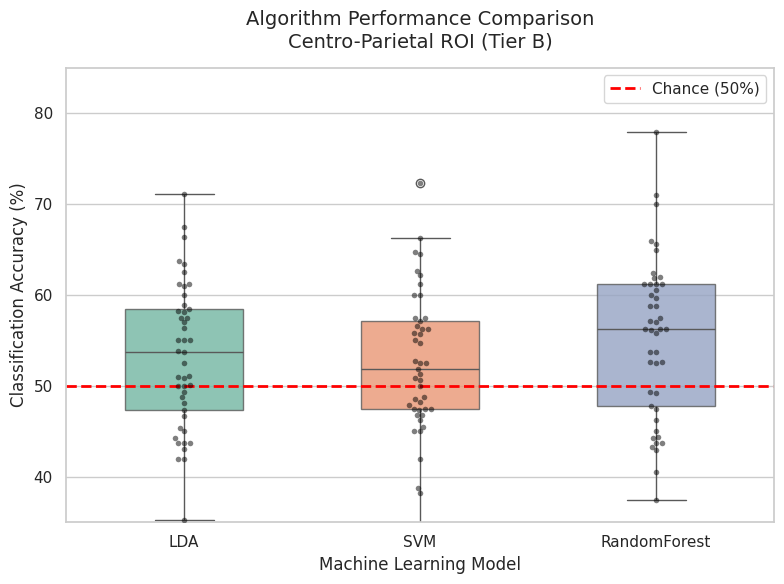

Generating Individual Subject Accuracy Plot for RF:


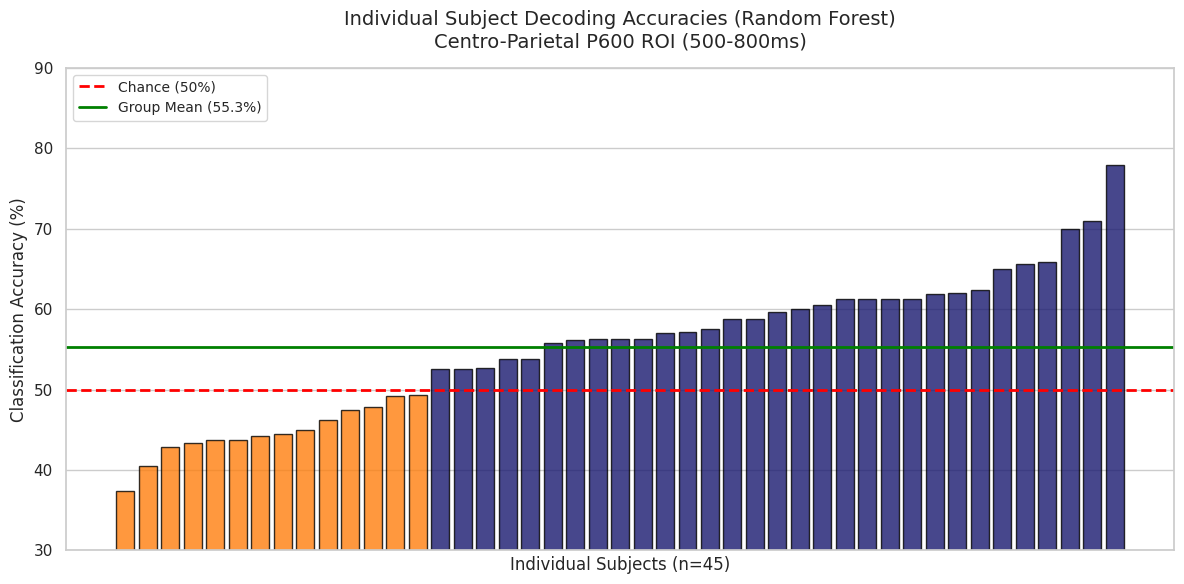

Calculating Aggregate Confusion Matrix for Random Forest (Tier B)...


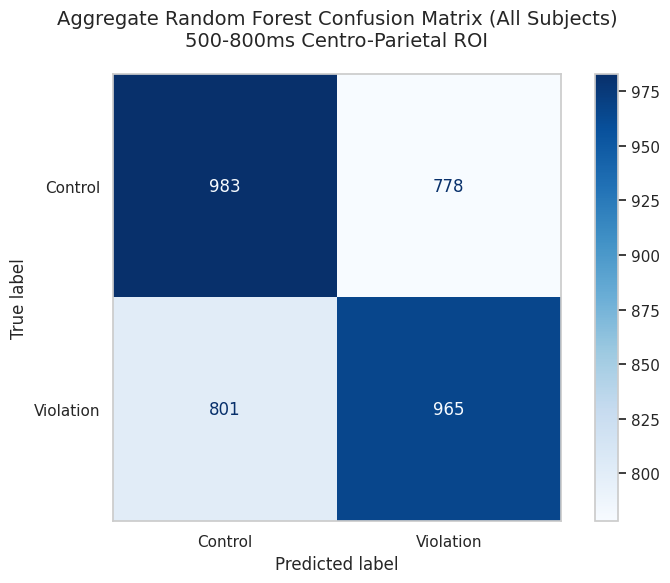

---- ALL VISUALIZATIONS COMPLETE AND SAVED!


In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

print("--- RESULT VISUALIZATIONS ---")

# ==============================================================================
# PLOT 1: MODEL COMPARISON (LDA vs SVM vs RF on Tier B)
# ==============================================================================
print("Generating Model Comparison Plot:")
tier_b_all_models = master_results_df[master_results_df['Config_Name'] == 'Tier_B_ROI_Aggregate']

plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")
sns.boxplot(x='Model', y='Accuracy', data=tier_b_all_models, palette='Set2', width=0.5, boxprops=dict(alpha=0.8))
sns.swarmplot(x='Model', y='Accuracy', data=tier_b_all_models, color='black', alpha=0.5, size=4)

plt.axhline(50, color='red', linestyle='--', linewidth=2, label='Chance (50%)')
plt.title('Algorithm Performance Comparison\nCentro-Parietal ROI (Tier B)', fontsize=14, pad=15)
plt.ylabel('Classification Accuracy (%)', fontsize=12)
plt.xlabel('Machine Learning Model', fontsize=12)
plt.ylim(35, 85)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "P600_Results", "Model_Comparison_Boxplot.png"), dpi=300)
plt.show()

# ==============================================================================
# PLOT 2: INDIVIDUAL SUBJECT ACCURACIES (Winning Model: Random Forest, Tier B)
# ==============================================================================
print("Generating Individual Subject Accuracy Plot for RF:")
rf_tier_b = tier_b_all_models[tier_b_all_models['Model'] == 'RandomForest'].copy()
rf_tier_b_sorted = rf_tier_b.sort_values(by='Accuracy').reset_index(drop=True)

accuracies = rf_tier_b_sorted['Accuracy'].values
subjects = rf_tier_b_sorted['Subject'].values

plt.figure(figsize=(12, 6))
colors = ['midnightblue' if acc >= 50 else '#ff7f0e' for acc in accuracies]
bars = plt.bar(range(len(subjects)), accuracies, color=colors, edgecolor='black', alpha=0.8)

# Reference lines
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Chance (50%)')
group_mean = np.mean(accuracies)
plt.axhline(y=group_mean, color='green', linestyle='-', linewidth=2, label=f'Group Mean ({group_mean:.1f}%)')

# Formatting
plt.title('Individual Subject Decoding Accuracies (Random Forest)\nCentro-Parietal P600 ROI (500-800ms)', fontsize=14, pad=15)
plt.xlabel('Individual Subjects (n=45)', fontsize=12)
plt.ylabel('Classification Accuracy (%)', fontsize=12)
plt.ylim(30, 90)
plt.xticks([])
plt.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(base_dir, "P600_Results", "Subject_Accuracy_Distribution_RF.png"), dpi=300)
plt.show()

# ==============================================================================
# PLOT 3: AGGREGATE CONFUSION MATRIX
# ==============================================================================
print("Calculating Aggregate Confusion Matrix for Random Forest (Tier B)...")

aggregate_cm = np.zeros((2, 2), dtype=int)
winning_clf = models['RandomForest']

for idx, row in analysis_df.iterrows():
    sub_id = row['participant_id']
    file_path = os.path.join(epochs_dir, f"{sub_id}_ML_clean_epo.fif")

    try:
        epochs = mne.read_epochs(file_path, preload=True, verbose=False)
        control_codes = [c for n, c in epochs.event_id.items() if '(110)' in n or '(115)' in n]
        violation_codes = [c for n, c in epochs.event_id.items() if '(220)' in n or '(225)' in n]
        valid_codes = control_codes + violation_codes

        epochs = epochs[np.isin(epochs.events[:, 2], valid_codes)]
        y = np.array([0 if ev in control_codes else 1 for ev in epochs.events[:, 2]])

        if len(np.unique(y)) < 2: continue

        # extracting Tier B x matrix
        epochs_tier = epochs.copy().crop(tmin=0.5, tmax=0.8).pick(roi_channels)
        X = epochs_tier.get_data()

        # Use cross_val_predict to get the actual 0s and 1s predictions
        y_pred = cross_val_predict(winning_clf, X, y, cv=cv, n_jobs=-1)

        # Add to aggregate matrix
        subject_cm = confusion_matrix(y, y_pred, labels=[0, 1])
        aggregate_cm += subject_cm

    except Exception as e:
        pass

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=aggregate_cm, display_labels=['Control', 'Violation'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Aggregate Random Forest Confusion Matrix (All Subjects)\n500-800ms Centro-Parietal ROI', pad=20, fontsize=14)
plt.grid(False) # Turn off the seaborn grid lines for the matrix
plt.tight_layout()
plt.savefig(os.path.join(base_dir, "P600_Results", "Group_Confusion_Matrix_RF.png"), dpi=300)
plt.show()

print("---- ALL VISUALIZATIONS COMPLETE AND SAVED!")